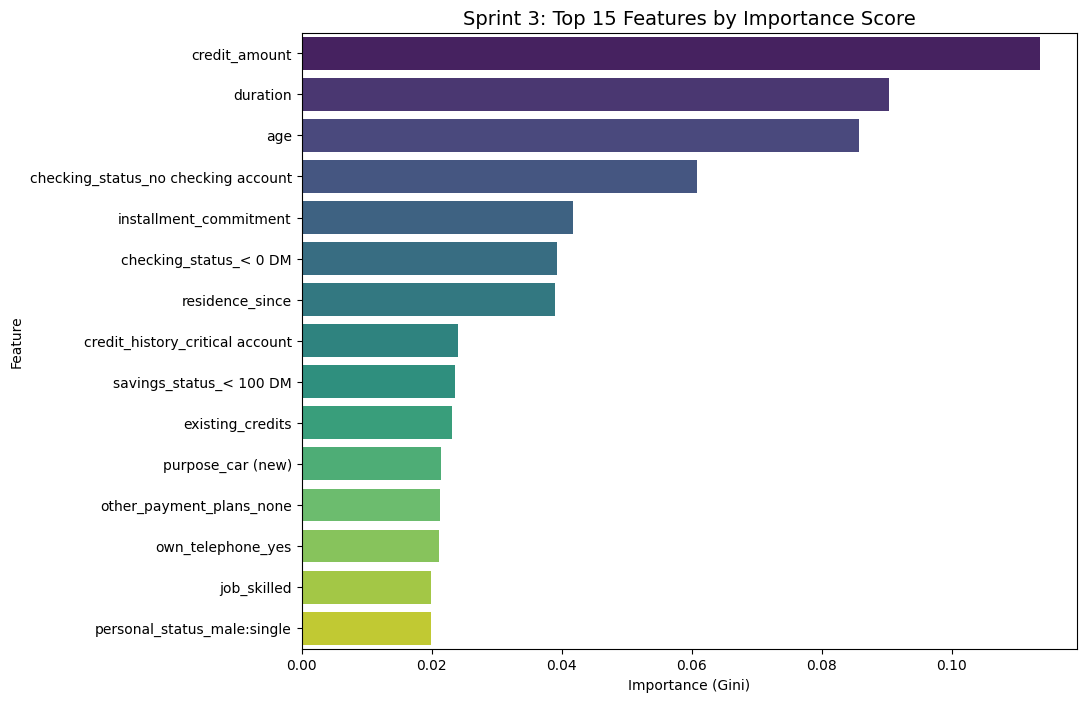

Total Features: 48
Features with < 0.5% importance (Candidates for removal): 6
                         Feature  Importance
47           foreign_worker_yes    0.004939
21              purpose_repairs    0.004536
44  job_unemp/unskilled non-res    0.003429
19               purpose_others    0.003130
16  purpose_domestic appliances    0.001977
22           purpose_retraining    0.001146
Top 3 Critical Features identified:
['credit_amount', 'duration', 'age']


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# 1. Load the preprocessed data (from Sprint 2)
df = pd.read_csv('../data/german_credit_mapped.csv')

# 2. Re-apply the encoding from Sprint 2 to get our 61 features
X = pd.get_dummies(df.drop('class', axis=1), drop_first=True)
y = df['class'].map({'Good Risk': 0, 'Bad Risk': 1})

# 3. Train a "Selection" Model
# We use Random Forest because it naturally calculates "Gini Importance"
selector_model = RandomForestClassifier(n_estimators=100, random_state=42)
selector_model.fit(X, y)

# 4. Extract and Rank Feature Importance
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': selector_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

imp = pd.Series(selector_model.feature_importances_, index=X.columns)
top_15 = imp.sort_values(ascending=False).head(15)


# 5. Visualize Top 15 Features
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importances.head(15), palette='viridis', hue='Feature', legend=False)
plt.title('Sprint 3: Top 15 Features by Importance Score', fontsize=14)
plt.xlabel('Importance (Gini)')
plt.show()


# 6. Identify the "Noise" (Features with almost zero importance)
zero_importance = importances[importances['Importance'] < 0.005]
print(f"Total Features: {len(X.columns)}")
print(f"Features with < 0.5% importance (Candidates for removal): {len(zero_importance)}\n {zero_importance} ")

# 7. Deliverable: Final Feature List
print("Top 3 Critical Features identified:")
print(top_15.index[:3].tolist())